In [1]:
#Environment Setup + Install Libraries
!pip install -q datasets tiktoken

In [2]:
import torch
import torch.nn as nn
from torch.nn import functional as F

import numpy as np
import matplotlib.pyplot as plt

import tiktoken
from datasets import load_dataset

from tqdm.auto import tqdm
from dataclasses import dataclass

import os, math, time

In [3]:
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    device = torch.device("cpu")
    print("No GPU found — go to Runtime > Change runtime type > GPU")

print("Using device:", device)

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU name: Tesla T4
Using device: cuda


In [4]:
SEED = 1337

torch.manual_seed(SEED)
np.random.seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Random seed set to {SEED}")

Random seed set to 1337


In [5]:
config = {
    # data
    "num_stories": 8000,          # subset of TinyStories we'll actually use
    "block_size": 128,            # max context length (tokens) the model sees at once

    # model
    "vocab_size": 50257,          # GPT-2 BPE vocab size (from tiktoken)
    "n_layer": 4,                 # number of transformer blocks
    "n_head": 8,                  # number of attention heads
    "n_embd": 256,                # embedding dimension
    "dropout": 0.1,

    # training
    "batch_size": 32,
    "learning_rate": 3e-4,
    "max_steps": 2000,
    "eval_interval": 200,
    "eval_iters": 50,

    "device": device,
    "seed": SEED,
}

for k, v in config.items():
    print(f"{k}: {v}")

num_stories: 8000
block_size: 128
vocab_size: 50257
n_layer: 4
n_head: 8
n_embd: 256
dropout: 0.1
batch_size: 32
learning_rate: 0.0003
max_steps: 2000
eval_interval: 200
eval_iters: 50
device: cuda
seed: 1337


In [6]:
#Dataset
dataset = load_dataset("roneneldan/TinyStories")
print(dataset)

README.md:   0%|          | 0.00/1.06k [00:00<?, ?B/s]

data/train-00000-of-00004-2d5a1467fff108(…):   0%|          | 0.00/249M [00:00<?, ?B/s]

data/train-00001-of-00004-5852b56a2bd28f(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

data/train-00002-of-00004-a26307300439e9(…):   0%|          | 0.00/246M [00:00<?, ?B/s]

data/train-00003-of-00004-d243063613e5a0(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

data/validation-00000-of-00001-869c898b5(…):   0%|          | 0.00/9.99M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2119719 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/21990 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 2119719
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 21990
    })
})


In [7]:
train_subset = dataset["train"].select(range(config["num_stories"]))
val_subset = dataset["validation"].select(range(500))  # small fixed validation set

print(f"Training stories: {len(train_subset)}")
print(f"Validation stories: {len(val_subset)}")

Training stories: 8000
Validation stories: 500


In [8]:
for i in range(3):
    print(f"--- Story {i+1} ---")
    print(train_subset[i]["text"])
    print()

--- Story 1 ---
One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt.

Lily went to her mom and said, "Mom, I found this needle. Can you share it with me and sew my shirt?" Her mom smiled and said, "Yes, Lily, we can share the needle and fix your shirt."

Together, they shared the needle and sewed the button on Lily's shirt. It was not difficult for them because they were sharing and helping each other. After they finished, Lily thanked her mom for sharing the needle and fixing her shirt. They both felt happy because they had shared and worked together.

--- Story 2 ---
Once upon a time, there was a little car named Beep. Beep loved to go fast and play in the sun. Beep was a healthy car because he always had good fuel. Good fuel made Beep happy and strong.

One day, Beep was driving in the park when he saw a big tree. The tree had

Average words per story: 165.5
Min words: 43
Max words: 837


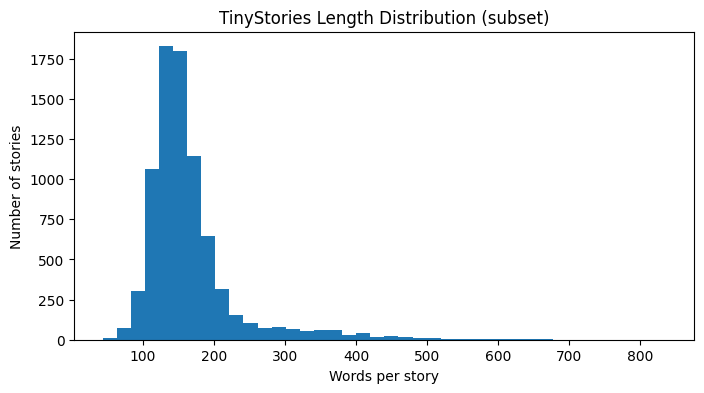

In [9]:
word_counts = [len(train_subset[i]["text"].split()) for i in range(len(train_subset))]

print(f"Average words per story: {np.mean(word_counts):.1f}")
print(f"Min words: {np.min(word_counts)}")
print(f"Max words: {np.max(word_counts)}")

plt.figure(figsize=(8, 4))
plt.hist(word_counts, bins=40)
plt.xlabel("Words per story")
plt.ylabel("Number of stories")
plt.title("TinyStories Length Distribution (subset)")
plt.show()

In [10]:
train_text = "\n".join(train_subset["text"])
val_text = "\n".join(val_subset["text"])

print(f"Total training characters: {len(train_text):,}")
print(f"Total validation characters: {len(val_text):,}")

Total training characters: 6,810,491
Total validation characters: 405,580


In [11]:
#Tokenization + Data Preparation
enc = tiktoken.get_encoding("gpt2")

print("Vocab size:", enc.n_vocab)
sample_encoded = enc.encode("Lily found a needle.")
print("Encoded:", sample_encoded)
print("Decoded back:", enc.decode(sample_encoded))

Vocab size: 50257
Encoded: [43, 813, 1043, 257, 17598, 13]
Decoded back: Lily found a needle.


In [12]:
train_ids = enc.encode(train_text)
val_ids = enc.encode(val_text)

print(f"Train tokens: {len(train_ids):,}")
print(f"Val tokens: {len(val_ids):,}")

train_ids = np.array(train_ids, dtype=np.uint16)
val_ids = np.array(val_ids, dtype=np.uint16)

Train tokens: 1,689,719
Val tokens: 100,954


In [13]:
os.makedirs("data", exist_ok=True)

train_ids.tofile("data/train.bin")
val_ids.tofile("data/val.bin")

print("Saved train.bin:", os.path.getsize("data/train.bin") / 1e6, "MB")
print("Saved val.bin:", os.path.getsize("data/val.bin") / 1e6, "MB")

Saved train.bin: 3.379438 MB
Saved val.bin: 0.201908 MB


In [14]:
train_data = np.memmap("data/train.bin", dtype=np.uint16, mode="r")
val_data = np.memmap("data/val.bin", dtype=np.uint16, mode="r")

print(f"train_data shape: {train_data.shape}")
print(f"val_data shape: {val_data.shape}")
print("First 10 train tokens:", train_data[:10])

train_data shape: (1689719,)
val_data shape: (100954,)
First 10 train tokens: [ 3198  1110    11   257  1310  2576  3706 20037  1043   257]


In [15]:
def get_batch(split, config):
    data = train_data if split == "train" else val_data
    block_size = config["block_size"]
    batch_size = config["batch_size"]

    # pick random starting points for each sequence in the batch
    ix = torch.randint(len(data) - block_size, (batch_size,))

    x = torch.stack([torch.from_numpy(data[i:i+block_size].astype(np.int64)) for i in ix])
    y = torch.stack([torch.from_numpy(data[i+1:i+1+block_size].astype(np.int64)) for i in ix])

    x, y = x.to(config["device"]), y.to(config["device"])
    return x, y

# quick test
xb, yb = get_batch("train", config)
print("Input batch shape:", xb.shape)
print("Target batch shape:", yb.shape)
print("First input sequence (first 10 tokens):", xb[0, :10])
print("First target sequence (first 10 tokens):", yb[0, :10])

Input batch shape: torch.Size([32, 128])
Target batch shape: torch.Size([32, 128])
First input sequence (first 10 tokens): tensor([26473,   373,  5901,   351,  1180,  9013,    13,  1318,   547, 18432],
       device='cuda:0')
First target sequence (first 10 tokens): tensor([  373,  5901,   351,  1180,  9013,    13,  1318,   547, 18432,    11],
       device='cuda:0')


In [16]:
example_input = xb[0].cpu().numpy()
example_target = yb[0].cpu().numpy()

print("INPUT  (first 15 tokens):", enc.decode(example_input[:15].tolist()))
print("TARGET (first 15 tokens):", enc.decode(example_target[:15].tolist()))

INPUT  (first 15 tokens):  tray was filled with different foods. There were treats, fruits and vegetables.
TARGET (first 15 tokens):  was filled with different foods. There were treats, fruits and vegetables. The


In [17]:
#Build Transformer
import torch.nn as nn
class Head(nn.Module):
    """One self-attention head."""
    def __init__(self, head_size, config):
        super().__init__()
        n_embd = config["n_embd"]
        block_size = config["block_size"]
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer("tril", torch.tril(torch.ones(block_size, block_size)))
        self.dropout = nn.Dropout(config["dropout"])

    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x)      # (B, T, head_size)
        q = self.query(x)    # (B, T, head_size)

        # attention scores ("how relevant is each token to each other token")
        wei = q @ k.transpose(-2, -1) * (k.shape[-1] ** -0.5)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))  # causal mask
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)

        v = self.value(x)
        out = wei @ v
        return out

In [18]:
class MultiHeadAttention(nn.Module):
    """Multiple self-attention heads running in parallel, then combined."""
    def __init__(self, num_heads, head_size, config):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size, config) for _ in range(num_heads)])
        self.proj = nn.Linear(head_size * num_heads, config["n_embd"])
        self.dropout = nn.Dropout(config["dropout"])

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)  # concatenate all heads' outputs
        out = self.dropout(self.proj(out))                    # combine back to n_embd size
        return out

In [19]:
class FeedForward(nn.Module):
    """Simple per-token MLP: expand, activate, project back down."""
    def __init__(self, config):
        super().__init__()
        n_embd = config["n_embd"]
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(config["dropout"]),
        )

    def forward(self, x):
        return self.net(x)

In [20]:
class Block(nn.Module):
    """One Transformer block: attention + feed-forward, each with a residual connection."""
    def __init__(self, config):
        super().__init__()
        n_embd = config["n_embd"]
        n_head = config["n_head"]
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size, config)
        self.ffwd = FeedForward(config)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))     # residual around attention
        x = x + self.ffwd(self.ln2(x))   # residual around feed-forward
        return x

In [21]:
class GPT(nn.Module):
    """A small GPT-style decoder-only Transformer."""
    def __init__(self, config):
        super().__init__()
        self.config = config
        vocab_size = config["vocab_size"]
        n_embd = config["n_embd"]
        block_size = config["block_size"]

        self.token_embedding = nn.Embedding(vocab_size, n_embd)
        self.position_embedding = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block(config) for _ in range(config["n_layer"])])
        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok_emb = self.token_embedding(idx)                                   # (B, T, n_embd)
        pos_emb = self.position_embedding(torch.arange(T, device=idx.device)) # (T, n_embd)
        x = tok_emb + pos_emb          # combine "what" + "where"
        x = self.blocks(x)             # pass through all 4 transformer blocks
        x = self.ln_f(x)               # final layer norm
        logits = self.lm_head(x)       # (B, T, vocab_size) — raw scores per possible next token

        loss = None
        if targets is not None:
            B, T, C = logits.shape
            logits_flat = logits.view(B * T, C)
            targets_flat = targets.view(B * T)
            loss = F.cross_entropy(logits_flat, targets_flat)
        return logits, loss

In [22]:
model = GPT(config).to(config["device"])

num_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {num_params:,}")

# reuse xb, yb from Milestone 3, Cell 5
logits, loss = model(xb, yb)
print("Logits shape:", logits.shape)
print("Loss:", loss.item())

Model parameters: 28,971,089
Logits shape: torch.Size([32, 128, 50257])
Loss: 11.007730484008789


In [23]:
#5:Training Loop + Train Model
optimizer = torch.optim.AdamW(model.parameters(), lr=config["learning_rate"])

def get_lr(step, config):
    """Cosine decay from learning_rate down to ~0 over max_steps."""
    progress = step / config["max_steps"]
    return config["learning_rate"] * 0.5 * (1 + math.cos(math.pi * progress))

# quick sanity check of the schedule
for s in [0, 500, 1000, 1500, 1999]:
    print(f"step {s}: lr = {get_lr(s, config):.6f}")

step 0: lr = 0.000300
step 500: lr = 0.000256
step 1000: lr = 0.000150
step 1500: lr = 0.000044
step 1999: lr = 0.000000


In [24]:
@torch.no_grad()
def estimate_loss(model, config):
    out = {}
    model.eval()
    for split in ["train", "val"]:
        losses = torch.zeros(config["eval_iters"])
        for k in range(config["eval_iters"]):
            xb, yb = get_batch(split, config)
            _, loss = model(xb, yb)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out

In [25]:
train_losses = []
val_losses = []
logged_steps = []

start_time = time.time()

for step in range(config["max_steps"]):
    # set learning rate for this step
    lr = get_lr(step, config)
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr

    # get a batch and compute loss
    xb, yb = get_batch("train", config)
    logits, loss = model(xb, yb)

    # backprop
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    # periodic evaluation
    if step % config["eval_interval"] == 0 or step == config["max_steps"] - 1:
        losses = estimate_loss(model, config)
        train_losses.append(losses["train"])
        val_losses.append(losses["val"])
        logged_steps.append(step)
        elapsed = time.time() - start_time
        print(f"step {step:4d} | train loss {losses['train']:.4f} | val loss {losses['val']:.4f} | lr {lr:.6f} | {elapsed:.1f}s elapsed")

print("Training complete.")

step    0 | train loss 10.7707 | val loss 10.7594 | lr 0.000300 | 6.3s elapsed
step  200 | train loss 4.5313 | val loss 4.4066 | lr 0.000293 | 48.3s elapsed
step  400 | train loss 4.0473 | val loss 3.9136 | lr 0.000271 | 93.4s elapsed
step  600 | train loss 3.7900 | val loss 3.6417 | lr 0.000238 | 136.1s elapsed
step  800 | train loss 3.6180 | val loss 3.4620 | lr 0.000196 | 179.6s elapsed
step 1000 | train loss 3.5096 | val loss 3.3700 | lr 0.000150 | 222.6s elapsed
step 1200 | train loss 3.4256 | val loss 3.3146 | lr 0.000104 | 265.7s elapsed
step 1400 | train loss 3.3607 | val loss 3.2525 | lr 0.000062 | 309.0s elapsed
step 1600 | train loss 3.3423 | val loss 3.2175 | lr 0.000029 | 352.2s elapsed
step 1800 | train loss 3.3483 | val loss 3.2313 | lr 0.000007 | 395.6s elapsed
step 1999 | train loss 3.3412 | val loss 3.2120 | lr 0.000000 | 438.5s elapsed
Training complete.


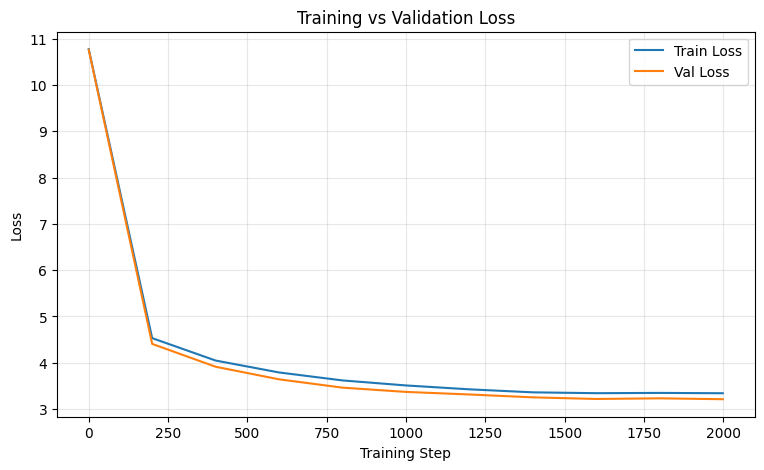

In [26]:
plt.figure(figsize=(9, 5))
plt.plot(logged_steps, train_losses, label="Train Loss")
plt.plot(logged_steps, val_losses, label="Val Loss")
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

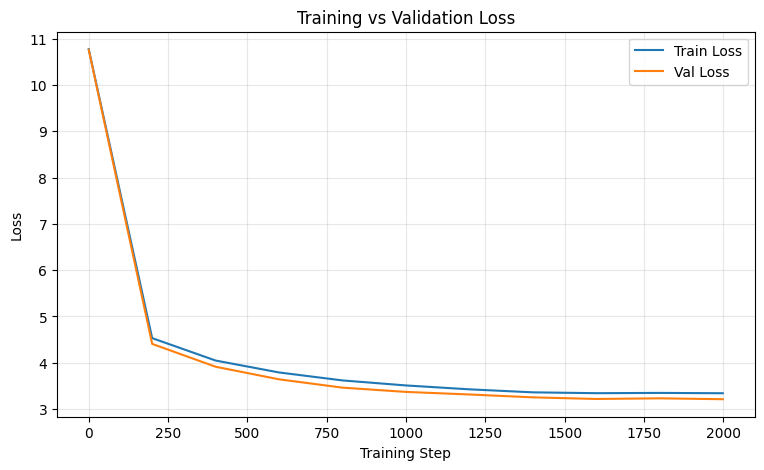

Saved to outputs/loss_curve.png
Final train loss: 3.3412
Final val loss: 3.2120


In [27]:
os.makedirs("outputs", exist_ok=True)

plt.figure(figsize=(9, 5))
plt.plot(logged_steps, train_losses, label="Train Loss")
plt.plot(logged_steps, val_losses, label="Val Loss")
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("outputs/loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved to outputs/loss_curve.png")
print(f"Final train loss: {train_losses[-1]:.4f}")
print(f"Final val loss: {val_losses[-1]:.4f}")

In [33]:
#6: Evaluate + Generate Text + Save Model
@torch.no_grad()
def generate(self, idx, max_new_tokens, temperature=1.0, top_k=50):
    self.eval()
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -self.config["block_size"]:]  # crop to last block_size tokens
        logits, _ = self(idx_cond)
        logits = logits[:, -1, :] / temperature  # only care about the last position's prediction

        if top_k is not None:
            v, _ = torch.topk(logits, top_k)
            logits[logits < v[:, [-1]]] = float('-inf')  # mask out everything below top-k

        probs = F.softmax(logits, dim=-1)
        idx_next = torch.multinomial(probs, num_samples=1)
        idx = torch.cat((idx, idx_next), dim=1)

    self.train()
    return idx

GPT.generate = generate  # attach the method to our GPT class

In [34]:
prompt = "Once upon a time"
prompt_ids = torch.tensor([enc.encode(prompt)], dtype=torch.long, device=config["device"])

generated = model.generate(prompt_ids, max_new_tokens=150, temperature=0.8, top_k=50)
generated_text = enc.decode(generated[0].tolist())

print(generated_text)

Once upon a time there was a young bear who liked to explore the park. One day, he thought it was a shiny and it was time to do anything. He looked under his friend and ran away. He said, "Letâ€

Lily, I think it is my car." 

Suddenly, so it will never got scared that even more careful.

But then, a boy started to do it. He came up. So, he saw a long mouse there of the door. He asked his dad to help him, "I'm so many things are now."

The end. He said, "That was so glad you."

Sam nodded and looked up the door. They could not see what was very


In [35]:
prompts = ["Once upon a time", "The little dog", "One day, a girl"]
temperatures = [0.5, 0.8, 1.2]

for prompt in prompts:
    print(f"\n===== PROMPT: '{prompt}' =====")
    for temp in temperatures:
        prompt_ids = torch.tensor([enc.encode(prompt)], dtype=torch.long, device=config["device"])
        generated = model.generate(prompt_ids, max_new_tokens=80, temperature=temp, top_k=50)
        text = enc.decode(generated[0].tolist())
        print(f"\n--- temperature={temp} ---")
        print(text)


===== PROMPT: 'Once upon a time' =====

--- temperature=0.5 ---
Once upon a time, there was a little girl named Lily. She loved to play with her family. One day, Lily was walking in her mommy. She was so excited to play with her friends. She was very sad because she was very happy and said, "Thank you, Lily. I'm glad you."

Lily and Ben said, "Yes, I will be careful with me. You

--- temperature=0.8 ---
Once upon a time there was a small creature. One day, he saw a little boy named Tim. He saw a little bug for it. Timmy was very kind and saw it was very excited.

As he saw his mom said, "Maybe you want to buy it?" The cat said, "Maybe, let's go look at the kite." Lily felt relieved and felt better. She couldn't

--- temperature=1.2 ---
Once upon a time, there were two a red old. They went to it and all lived in the living room. Every night, but he couldn't seem his pocket at each other.

The squirrel was so amazed again and saw Tom didn't want to be able. She asked Sam to the world an

In [36]:
os.makedirs("outputs", exist_ok=True)

checkpoint = {
    "model_state_dict": model.state_dict(),
    "config": config,
    "final_train_loss": train_losses[-1],
    "final_val_loss": val_losses[-1],
}

torch.save(checkpoint, "outputs/model.pt")
print("Model saved to outputs/model.pt")
print("File size:", os.path.getsize("outputs/model.pt") / 1e6, "MB")

Model saved to outputs/model.pt
File size: 118.036411 MB


In [37]:
checkpoint = torch.load("outputs/model.pt", map_location=config["device"])

loaded_model = GPT(checkpoint["config"]).to(config["device"])
loaded_model.load_state_dict(checkpoint["model_state_dict"])
loaded_model.eval()

print("Loaded model — final train loss was:", checkpoint["final_train_loss"])
print("Loaded model — final val loss was:", checkpoint["final_val_loss"])

test_prompt = torch.tensor([enc.encode("The little dog")], dtype=torch.long, device=config["device"])
test_output = loaded_model.generate(test_prompt, max_new_tokens=60, temperature=0.8, top_k=50)
print("\nGenerated from reloaded model:")
print(enc.decode(test_output[0].tolist()))

Loaded model — final train loss was: 3.3411684036254883
Loaded model — final val loss was: 3.2120361328125

Generated from reloaded model:
The little dog. They worked like to play together.
Once upon a time, there was a little girl named Lily. She loved to go on an enormous garden. One day, her hands, she wanted to play with her toy car. He knew that the ball would be careful with the yard and give him
